# CriticalGraphRAG — Evaluación de KPIs (Incremento 04)

**ITBA — Ciencia de Datos Aplicada**

Notebook autónomo que valida sobre la API deployada los KPIs definidos en el Incremento 01.

**API:** `https://critigal-graph-rag.onrender.com/chat`

## KPIs a validar

| # | KPI | Umbral |
|---|-----|--------|
| 1 | Exactitud factual sobre el conjunto de evaluación | **≥ 80%** |
| 2 | Tasa de alucinación en respuestas generadas | **< 20%** |
| 3 | Tool routing accuracy (tool usado == tool esperado) | **≥ 80%** |
| 4 | Tiempo de respuesta promedio por consulta (`latency_ms` del server) | **< 5 s** |

## Estrategia

Conjunto de **9 preguntas** balanceadas (3 por cada tool del agente) cargado desde `tests/eval_set.yaml`. Ground truth de las factuales: queries Cypher determinísticas en `tests/gold_cypher.yaml` corridas offline contra Neo4j. Para las descriptivas (`similarity_search`) la ground truth son keywords del contenido narrativo; el scoring usa recall sobre tokens. Una sola pasada por la API mide simultáneamente exactitud, alucinación, tool routing y latencia. Scoring inline — el notebook no depende de scripts externos.

## 1. Setup

In [38]:
from __future__ import annotations

import re
import time

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display, Markdown

API_BASE = "https://critigal-graph-rag.onrender.com"
CHAT_URL = f"{API_BASE}/chat"
HEALTH_URL = f"{API_BASE}/health"
TIMEOUT_S = 120


def ask(question: str) -> dict:
    """Llama a la API; devuelve dict con response/used_tool/latency_ms/latency_wall_ms/error.

    `latency_ms` viene del server (tiempo del agente, sin red); `latency_wall_ms`
    es el wall-clock del cliente — se usa como fallback cuando hay error o falta el campo.
    """
    t0 = time.monotonic()
    try:
        r = requests.post(CHAT_URL, json={"message": question}, timeout=TIMEOUT_S)
        r.raise_for_status()
        wall_ms = (time.monotonic() - t0) * 1000
        body = r.json()
        return {
            "response": body["response"],
            "used_tool": body.get("used_tool"),
            "latency_ms": body.get("latency_ms"),
            "latency_wall_ms": wall_ms,
            "error": "",
        }
    except Exception as exc:
        wall_ms = (time.monotonic() - t0) * 1000
        return {
            "response": "",
            "used_tool": None,
            "latency_ms": None,
            "latency_wall_ms": wall_ms,
            "error": str(exc),
        }


# Warmup — Render free tier puede dormir el contenedor; evita sesgar la latencia.
try:
    requests.get(HEALTH_URL, timeout=30)
    print("API warmup OK")
except Exception as exc:
    print(f"Warmup falló (continuamos): {exc}")

API warmup OK


## 2. Conjunto de evaluación

9 preguntas balanceadas (3 por tool del agente), cargadas desde `tests/eval_set.yaml`. Ground truth de las factuales: queries Cypher determinísticas en `tests/gold_cypher.yaml`, corridas offline contra Neo4j. Para las descriptivas (`similarity_search`) el `expected` son keywords del contenido narrativo — el scoring usa recall sobre tokens normalizados.

In [39]:
from pathlib import Path

import yaml

EVAL_SET_PATH = Path("../tests/eval_set.yaml")
with EVAL_SET_PATH.open(encoding="utf-8") as f:
    EVAL_SET = yaml.safe_load(f)["questions"]

df_eval = pd.DataFrame(EVAL_SET)
display(df_eval[["id", "tool_target", "tipo", "pregunta", "expected"]])

,id,tool_target,tipo,pregunta,expected
0,cq1,cypher_query,factual_numeric,¿Cuántos eventos registró ACLED en Israel dura...,768
1,cq2,cypher_query,factual_numeric,¿Cuántas fatalidades totales se registraron en...,1773
2,cq3,cypher_query,factual_numeric,¿Cuántos eventos registró ACLED en el distrito...,610
3,t2c1,text2cypher,factual_numeric,¿En cuántos días distintos de 2023 hubo al men...,347
4,t2c2,text2cypher,factual_numeric,¿Cuántos eventos en Israel en 2023 tuvieron ex...,4064
5,t2c3,text2cypher,factual_numeric,¿Cuántos actores únicos participaron en evento...,74
6,ss1,similarity_search,descriptive,¿Cómo se describen los ataques con cohetes reg...,cohetes Hamas Gaza Sderot Ashkelon disparados ...
7,ss2,similarity_search,descriptive,Describí incidentes que ocurrieron en zonas fr...,Hezbollah frontera norte Líbano antitanque coh...
8,ss3,similarity_search,descriptive,¿Sobre qué temas o reclamos se manifestaron lo...,protestas Tel Aviv reforma judicial manifestan...


## 3. Scoring inline

Dos métodos según el tipo de pregunta:

- **`numeric_match`** (factuales): extrae todos los números de la respuesta y compara el más cercano al expected. Tolerancia ±5% (score = 1.0); error mayor reduce el score linealmente.
- **`keyword_recall`** (descriptivas): fracción de keywords esperadas presentes en la respuesta. `recall = |expected ∩ pred| / |expected|`. Normaliza acentos y mayúsculas. No penaliza respuestas verbosas (a diferencia de Jaccard, que sí lo hace porque infla la unión).

**Umbral de alucinación:**

| Método | Umbral `hallucinated` |
|--------|-----------------------|
| `numeric_match`  | score < 0.5 (>50% de error sobre el valor real) |
| `keyword_recall` | score < 0.4 (menos del 40% de keywords presentes) |

In [40]:
from __future__ import annotations

import unicodedata


def extract_numbers(text: str) -> list[float]:
    """Extrae TODOS los números (enteros, decimales, con separadores de miles) del texto."""
    out: list[float] = []
    for raw in re.findall(r"-?\d{1,3}(?:[.,]\d{3})+(?:[.,]\d+)?|-?\d+(?:[.,]\d+)?", text or ""):
        s = raw
        if "." in s and "," in s:
            # ambos presentes → asumir formato ES: '.' miles, ',' decimal
            s = s.replace(".", "").replace(",", ".")
        elif "," in s:
            # solo coma: si parece decimal (1-2 dígitos después) tratarla como tal; si no, miles
            tail = s.split(",")[-1]
            s = s.replace(",", ".") if len(tail) <= 2 else s.replace(",", "")
        try:
            out.append(float(s))
        except ValueError:
            continue
    return out


def best_number_match(expected: float, candidates: list[float]) -> float | None:
    """Candidato con menor error relativo respecto a `expected`. None si no hay candidatos."""
    if not candidates:
        return None
    if expected == 0:
        return min(candidates, key=abs)
    return min(candidates, key=lambda x: abs(x - expected) / abs(expected))


def strip_accents(text: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFD", text) if unicodedata.category(c) != "Mn")


def tokenize(text: str) -> set[str]:
    text = strip_accents((text or "").lower())
    return {t for t in re.split(r"[^\w]+", text) if t and len(t) > 2}


def score_response(pred: str, expected: str, tipo: str) -> dict:
    """Devuelve {method, score, hallucinated, best_num}."""
    pred, expected = (pred or "").strip(), (expected or "").strip()

    if tipo == "factual_numeric":
        exp_nums = extract_numbers(expected)
        if not exp_nums:
            return {"method": "numeric_match", "score": 0.0, "hallucinated": True, "best_num": None}
        exp_n = exp_nums[0]
        candidates = extract_numbers(pred)
        best = best_number_match(exp_n, candidates)
        if best is None:
            return {"method": "numeric_match", "score": 0.0, "hallucinated": True, "best_num": None}
        if exp_n == 0:
            score = 1.0 if best == 0 else 0.0
        else:
            err = abs(best - exp_n) / abs(exp_n)
            score = 1.0 if err <= 0.05 else max(0.0, 1.0 - err)
        return {"method": "numeric_match", "score": float(score),
                "hallucinated": score < 0.5, "best_num": best}

    # descriptive → recall sobre keywords esperadas
    exp_t, pred_t = tokenize(expected), tokenize(pred)
    if not exp_t:
        return {"method": "keyword_recall", "score": 0.0, "hallucinated": True, "best_num": None}
    recall = len(exp_t & pred_t) / len(exp_t)
    return {"method": "keyword_recall", "score": float(recall),
            "hallucinated": recall < 0.4, "best_num": None}

## 4. Evaluación contra la API

Loop sobre el conjunto, **N iteraciones por pregunta** (N=`N_RUNS`). Las iteraciones múltiples capturan la varianza propia del LLM (no determinístico) y permiten reportar mean ± std por pregunta y por KPI.

In [41]:
N_RUNS = 5

# Consultas a la API — recolecta response + latencia + tool usado, sin scoring.
api_results = []
total = len(EVAL_SET) * N_RUNS
i = 0
for run in range(1, N_RUNS + 1):
    for item in EVAL_SET:
        i += 1
        print(f"[{i}/{total}] run={run} id={item['id']} — {item['pregunta'][:60]}...")
        result = ask(item["pregunta"])
        # latency_ms del server (tiempo del agente). Fallback a wall-clock solo si
        # la API no lo devolvió (típicamente porque hubo error en la request).
        latency_ms = (
            result["latency_ms"] if result["latency_ms"] is not None
            else result["latency_wall_ms"]
        )
        api_results.append({
            "run": run,
            "id": item["id"],
            "tool_target": item["tool_target"],
            "tool_used": result["used_tool"],
            "tool_match": result["used_tool"] == item["tool_target"],
            "tipo": item["tipo"],
            "pregunta": item["pregunta"],
            "expected": item["expected"],
            "response": result["response"],
            "latency_ms": round(latency_ms, 1),
            "latency_wall_ms": round(result["latency_wall_ms"], 1),
            "error": result["error"],
        })

responses_df = pd.DataFrame(api_results)
print(f"\n{len(responses_df)} respuestas recolectadas.")

[1/45] run=1 id=cq1 — ¿Cuántos eventos registró ACLED en Israel durante octubre de...
[2/45] run=1 id=cq2 — ¿Cuántas fatalidades totales se registraron en Israel durant...
[3/45] run=1 id=cq3 — ¿Cuántos eventos registró ACLED en el distrito de Tel Aviv d...
[4/45] run=1 id=t2c1 — ¿En cuántos días distintos de 2023 hubo al menos un evento e...
[5/45] run=1 id=t2c2 — ¿Cuántos eventos en Israel en 2023 tuvieron exactamente 0 fa...
[6/45] run=1 id=t2c3 — ¿Cuántos actores únicos participaron en eventos en el distri...
[7/45] run=1 id=ss1 — ¿Cómo se describen los ataques con cohetes registrados en Is...
[8/45] run=1 id=ss2 — Describí incidentes que ocurrieron en zonas fronterizas con ...
[9/45] run=1 id=ss3 — ¿Sobre qué temas o reclamos se manifestaron los protestantes...
[10/45] run=2 id=cq1 — ¿Cuántos eventos registró ACLED en Israel durante octubre de...
[11/45] run=2 id=cq2 — ¿Cuántas fatalidades totales se registraron en Israel durant...
[12/45] run=2 id=cq3 — ¿Cuántos eventos registró 

In [42]:
# Cálculo de scores sobre las respuestas — se puede re-ejecutar sin volver a llamar a la API.
scored = []
for r in responses_df.to_dict("records"):
    s = score_response(r["response"], r["expected"], r["tipo"])
    scored.append({
        **r,
        "score": s["score"],
        "score_method": s["method"],
        "hallucinated": s["hallucinated"],
        "best_num": s["best_num"],
    })

raw_df = pd.DataFrame(scored)

# Agregado por pregunta — mean/std a través de las corridas
agg_df = raw_df.groupby(["id", "tool_target", "tipo"], as_index=False).agg(
    score_mean=("score", "mean"),
    score_std=("score", "std"),
    latency_mean_ms=("latency_ms", "mean"),
    latency_std_ms=("latency_ms", "std"),
    hallucination_rate=("hallucinated", "mean"),
    tool_match_rate=("tool_match", "mean"),
    n_runs=("score", "count"),
)

# Tabla cruda: pregunta + esperado vs obtenido + latencia + score por iteración
print(f"Resultados crudos ({len(raw_df)} filas):")
raw_show = raw_df[["run", "id", "tool_target", "tool_used", "tool_match",
                   "pregunta", "expected", "response",
                   "latency_ms", "score", "hallucinated"]].copy()
raw_show["pregunta"] = raw_show["pregunta"].str.slice(0, 80) + "…"
raw_show["response"] = raw_show["response"].fillna("").str.slice(0, 300)
display(raw_show.style.format({"score": "{:.2f}", "latency_ms": "{:.0f}"}))

Resultados crudos (45 filas):


,run,id,tool_target,tool_used,tool_match,pregunta,expected,response,latency_ms,score,hallucinated
0,1,cq1,cypher_query,cypher_query,True,¿Cuántos eventos registró ACLED en Israel durante octubre de 2023?…,768,ACLED registró 768 eventos en Israel durante octubre de 2023.,2413,1.00,False
1,1,cq2,cypher_query,cypher_query,True,¿Cuántas fatalidades totales se registraron en Israel durante 2023?…,1773,Se registraron un total de 1773 fatalidades en Israel durante 2023.,2166,1.00,False
2,1,cq3,cypher_query,cypher_query,True,¿Cuántos eventos registró ACLED en el distrito de Tel Aviv durante todo el año 2…,610,ACLED registró 610 eventos en el distrito de Tel Aviv durante todo el año 2023.,2088,1.00,False
3,1,t2c1,text2cypher,text2cypher,True,¿En cuántos días distintos de 2023 hubo al menos un evento en Israel?…,347,"En 2023, hubo eventos en Israel en 347 días distintos.",5017,1.00,False
4,1,t2c2,text2cypher,text2cypher,True,¿Cuántos eventos en Israel en 2023 tuvieron exactamente 0 fatalidades?…,4064,"En Israel, en 2023, hubo 4064 eventos con exactamente 0 fatalidades.",3276,1.00,False
5,1,t2c3,text2cypher,text2cypher,True,¿Cuántos actores únicos participaron en eventos en el distrito de Tel Aviv duran…,74,"En el distrito de Tel Aviv, 74 actores únicos participaron en eventos durante 2023.",4736,1.00,False
6,1,ss1,similarity_search,similarity_search,True,¿Cómo se describen los ataques con cohetes registrados en Israel en 2023?…,cohetes Hamas Gaza Sderot Ashkelon disparados Israel,"Los ataques con cohetes registrados en Israel en 2023 se describen de la siguiente manera: * **Perpetradores:** Principalmente el PIJ (Yihad Islámica Palestina) y militantes de Hamás, incluyendo operativos de Hamás desde el Líbano. * **Orígenes:** Lanzados desde Gaza y el Líbano. * **Zonas af",5783,0.57,False
7,1,ss2,similarity_search,similarity_search,True,Describí incidentes que ocurrieron en zonas fronterizas con Líbano…,Hezbollah frontera norte Líbano antitanque cohetes HaZafon,"Aquí tienes una descripción de los incidentes ocurridos en zonas fronterizas con Líbano: * **7 de octubre de 2023:** Fuerzas israelíes abrieron fuego contra militantes de Hezbollah en motocicletas que intentaron cruzar la frontera israelí cerca de Metulla (Zefat, HaZafon). * **18 de octubre de",5001,0.71,False
8,1,ss3,similarity_search,similarity_search,True,¿Sobre qué temas o reclamos se manifestaron los protestantes en Tel Aviv durante…,protestas Tel Aviv reforma judicial manifestantes gobierno Netanyahu,"En Tel Aviv durante 2023, los protestantes se manifestaron principalmente sobre los siguientes temas: * **Reforma judicial propuesta por la coalición liderada por Netanyahu:** * La mayoría de las protestas fueron en contra de estas reformas, que incluían permitir a la Knesset anular decisio",4288,0.75,False
9,2,cq1,cypher_query,cypher_query,True,¿Cuántos eventos registró ACLED en Israel durante octubre de 2023?…,768,ACLED registró 768 eventos en Israel durante octubre de 2023.,2164,1.00,False


## 5. Cómputo de KPIs

In [43]:
import numpy as np

# KPI por corrida: agrega las 9 preguntas dentro de cada run, después promedia.
# accuracy_run = % preguntas no alucinadas en ese run.
per_run = raw_df.groupby("run").agg(
    accuracy=("hallucinated", lambda s: (~s).mean()),
    hallucination_rate=("hallucinated", "mean"),
    tool_match_rate=("tool_match", "mean"),
    latency_avg_s=("latency_ms", lambda s: s.mean() / 1000),
)

acc_mean, acc_std = per_run["accuracy"].mean(), per_run["accuracy"].std(ddof=1)
hal_mean, hal_std = per_run["hallucination_rate"].mean(), per_run["hallucination_rate"].std(ddof=1)
tm_mean, tm_std = per_run["tool_match_rate"].mean(), per_run["tool_match_rate"].std(ddof=1)
lat_mean, lat_std = per_run["latency_avg_s"].mean(), per_run["latency_avg_s"].std(ddof=1)
lat_p95 = raw_df["latency_ms"].quantile(0.95) / 1000

kpis = pd.DataFrame([
    {"KPI": "Exactitud factual",
     "Valor (mean ± std)": f"{acc_mean*100:.1f}% ± {acc_std*100:.1f}%",
     "Umbral": "≥ 80%",
     "Estado": "✓" if acc_mean >= 0.80 else "✗"},
    {"KPI": "Tasa de alucinación",
     "Valor (mean ± std)": f"{hal_mean*100:.1f}% ± {hal_std*100:.1f}%",
     "Umbral": "< 20%",
     "Estado": "✓" if hal_mean < 0.20 else "✗"},
    {"KPI": "Tool routing accuracy",
     "Valor (mean ± std)": f"{tm_mean*100:.1f}% ± {tm_std*100:.1f}%",
     "Umbral": "≥ 80%",
     "Estado": "✓" if tm_mean >= 0.80 else "✗"},
    {"KPI": "Latencia promedio (s)",
     "Valor (mean ± std)": f"{lat_mean:.2f} ± {lat_std:.2f}",
     "Umbral": "< 5",
     "Estado": "✓" if lat_mean < 5 else "✗"},
])
display(kpis)

print(f"\nKPI por corrida (n={len(per_run)}):")
display(per_run.style.format({
    "accuracy": "{:.3f}",
    "hallucination_rate": "{:.3f}",
    "tool_match_rate": "{:.3f}",
    "latency_avg_s": "{:.2f}",
}))
print(f"\nLatencia p95 global: {lat_p95:.2f}s (informativo)")

,KPI,Valor (mean ± std),Umbral,Estado
0,Exactitud factual,100.0% ± 0.0%,≥ 80%,✓
1,Tasa de alucinación,0.0% ± 0.0%,< 20%,✓
2,Tool routing accuracy,100.0% ± 0.0%,≥ 80%,✓
3,Latencia promedio (s),4.17 ± 0.36,< 5,✓



KPI por corrida (n=5):


,accuracy,hallucination_rate,tool_match_rate,latency_avg_s
run,,,,
1,1.000,0.000,1.000,3.86
2,1.000,0.000,1.000,4.01
3,1.000,0.000,1.000,4.24
4,1.000,0.000,1.000,4.76
5,1.000,0.000,1.000,3.97



Latencia p95 global: 7.10s (informativo)


## 6. Dashboard

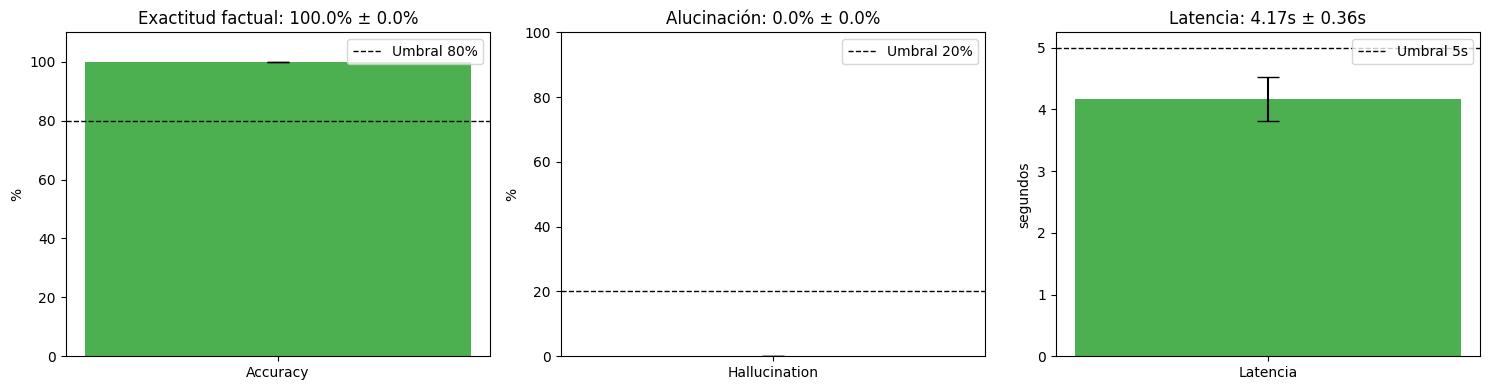

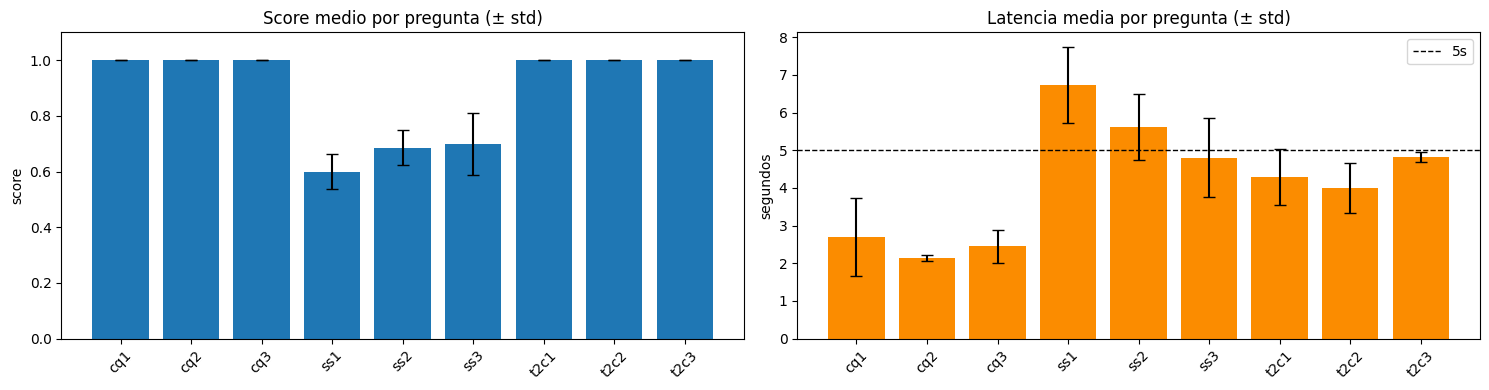

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# KPI 1: Accuracy
ax = axes[0]
ax.bar(["Accuracy"], [acc_mean * 100],
       yerr=[acc_std * 100], capsize=8,
       color="#4CAF50" if acc_mean >= 0.80 else "#E53935")
ax.axhline(80, color="black", linestyle="--", linewidth=1, label="Umbral 80%")
ax.set_ylim(0, 110)
ax.set_ylabel("%")
ax.set_title(f"Exactitud factual: {acc_mean*100:.1f}% ± {acc_std*100:.1f}%")
ax.legend()

# KPI 2: Hallucination
ax = axes[1]
ax.bar(["Hallucination"], [hal_mean * 100],
       yerr=[hal_std * 100], capsize=8,
       color="#4CAF50" if hal_mean < 0.20 else "#E53935")
ax.axhline(20, color="black", linestyle="--", linewidth=1, label="Umbral 20%")
ax.set_ylim(0, 100)
ax.set_ylabel("%")
ax.set_title(f"Alucinación: {hal_mean*100:.1f}% ± {hal_std*100:.1f}%")
ax.legend()

# KPI 3: Latency
ax = axes[2]
ax.bar(["Latencia"], [lat_mean],
       yerr=[lat_std], capsize=8,
       color="#4CAF50" if lat_mean < 5 else "#E53935")
ax.axhline(5, color="black", linestyle="--", linewidth=1, label="Umbral 5s")
ax.set_ylabel("segundos")
ax.set_title(f"Latencia: {lat_mean:.2f}s ± {lat_std:.2f}s")
ax.legend()

plt.tight_layout()
plt.show()

# Bonus: score y latencia por pregunta con barras de error
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
order = agg_df["id"].tolist()

axes[0].bar(order, agg_df["score_mean"], yerr=agg_df["score_std"].fillna(0), capsize=4)
axes[0].set_title("Score medio por pregunta (± std)")
axes[0].set_ylabel("score")
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(order, agg_df["latency_mean_ms"] / 1000,
            yerr=(agg_df["latency_std_ms"] / 1000).fillna(0), capsize=4, color="#FB8C00")
axes[1].axhline(5, color="black", linestyle="--", linewidth=1, label="5s")
axes[1].set_title("Latencia media por pregunta (± std)")
axes[1].set_ylabel("segundos")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Detalle por pregunta

In [45]:
# Resumen de qué tool usó el agente por pregunta (puede variar entre runs si el routing es inestable).
tools_used = (
    raw_df.groupby("id")["tool_used"]
    .apply(lambda s: ", ".join(f"{t or '∅'}×{n}" for t, n in s.value_counts(dropna=False).items()))
    .rename("tools_used")
    .reset_index()
)

agg_show = agg_df.merge(tools_used, on="id", how="left")
cols = ["id", "tool_target", "tipo", "tools_used", "score_mean",
        "latency_mean_ms", "hallucination_rate", "tool_match_rate", "n_runs"]

print("Agregado por pregunta:")
display(agg_show[cols].style.format({
    "score_mean": "{:.2f}",
    "latency_mean_ms": "{:.0f}",
    "hallucination_rate": "{:.2f}",
    "tool_match_rate": "{:.2f}",
}))

by_tool = raw_df.groupby("tool_target").agg(
    n=("id", "count"),
    accuracy=("hallucinated", lambda s: (~s).mean()),
    hallucination_rate=("hallucinated", "mean"),
    tool_match_rate=("tool_match", "mean"),
    latency_mean_ms=("latency_ms", "mean"),
).round(3)
print("\nAgregado por tool esperado:")
display(by_tool)

# Matriz target vs used — diagnóstica errores de routing del agente.
print("\nMatriz de confusión (tool_target vs tool_used):")
display(pd.crosstab(
    raw_df["tool_target"],
    raw_df["tool_used"].fillna("∅"),
    margins=True,
    margins_name="total",
))

Agregado por pregunta:


,id,tool_target,tipo,tools_used,score_mean,latency_mean_ms,hallucination_rate,tool_match_rate,n_runs
0,cq1,cypher_query,factual_numeric,cypher_query×5,1.00,2694,0.00,1.00,5
1,cq2,cypher_query,factual_numeric,cypher_query×5,1.00,2135,0.00,1.00,5
2,cq3,cypher_query,factual_numeric,cypher_query×5,1.00,2447,0.00,1.00,5
3,ss1,similarity_search,descriptive,similarity_search×5,0.60,6730,0.00,1.00,5
4,ss2,similarity_search,descriptive,similarity_search×5,0.69,5617,0.00,1.00,5
5,ss3,similarity_search,descriptive,similarity_search×5,0.70,4807,0.00,1.00,5
6,t2c1,text2cypher,factual_numeric,text2cypher×5,1.00,4287,0.00,1.00,5
7,t2c2,text2cypher,factual_numeric,text2cypher×5,1.00,3995,0.00,1.00,5
8,t2c3,text2cypher,factual_numeric,text2cypher×5,1.00,4812,0.00,1.00,5



Agregado por tool esperado:


,n,accuracy,hallucination_rate,tool_match_rate,latency_mean_ms
tool_target,,,,,
cypher_query,15,1.0,0.0,1.0,2425.200
similarity_search,15,1.0,0.0,1.0,5718.200
text2cypher,15,1.0,0.0,1.0,4364.533



Matriz de confusión (tool_target vs tool_used):


tool_used,cypher_query,similarity_search,text2cypher,total
tool_target,,,,
cypher_query,15,0,0,15
similarity_search,0,15,0,15
text2cypher,0,0,15,15
total,15,15,15,45


## 8. Inspección cualitativa (preguntas + respuestas)

Para revisión manual de los casos limítrofes.

In [46]:
for qid in agg_df["id"]:
    qrows = raw_df[raw_df["id"] == qid].sort_values("run")
    first = qrows.iloc[0]
    agg = agg_df[agg_df["id"] == qid].iloc[0]
    display(Markdown(
        f"### {qid} — {first['tool_target']}\n\n"
        f"**Pregunta:** {first['pregunta']}\n\n"
        f"**Esperado:** `{first['expected']}`\n\n"
        f"**Score medio:** {agg['score_mean']:.2f} ± {agg['score_std']:.2f}  |  "
        f"**Latencia:** {agg['latency_mean_ms']:.0f}ms ± {agg['latency_std_ms']:.0f}ms  |  "
        f"**Hallu rate:** {agg['hallucination_rate']:.2f}  |  "
        f"**Tool match:** {agg['tool_match_rate']:.2f}"
    ))
    for _, r in qrows.iterrows():
        flag = "✗" if r["hallucinated"] else "✓"
        tool_mark = "✓" if r["tool_match"] else "✗"
        resp = r["response"] or f"(error: {r['error']})"
        # Render la respuesta como <pre> para preservar saltos de línea, listas y
        # cualquier markdown literal sin que se rompa el blockquote en líneas en blanco.
        from html import escape
        resp_html = escape(resp)
        display(Markdown(
            f"- **Run {r['run']}** {flag} score={r['score']:.2f} | "
            f"{r['latency_ms']:.0f}ms | tool={r['tool_used'] or '∅'} {tool_mark}\n\n"
            f"<pre style='white-space:pre-wrap;background:#f6f8fa;padding:8px;"
            f"border-left:3px solid #ccc;margin:4px 0 12px 1.5em;'>{resp_html}</pre>"
        ))

### cq1 — cypher_query

**Pregunta:** ¿Cuántos eventos registró ACLED en Israel durante octubre de 2023?

**Esperado:** `768`

**Score medio:** 1.00 ± 0.00  |  **Latencia:** 2694ms ± 1033ms  |  **Hallu rate:** 0.00  |  **Tool match:** 1.00

- **Run 1** ✓ score=1.00 | 2413ms | tool=cypher_query ✓

<pre style='white-space:pre-wrap;background:#f6f8fa;padding:8px;border-left:3px solid #ccc;margin:4px 0 12px 1.5em;'>ACLED registró 768 eventos en Israel durante octubre de 2023.</pre>

- **Run 2** ✓ score=1.00 | 2164ms | tool=cypher_query ✓

<pre style='white-space:pre-wrap;background:#f6f8fa;padding:8px;border-left:3px solid #ccc;margin:4px 0 12px 1.5em;'>ACLED registró 768 eventos en Israel durante octubre de 2023.</pre>

- **Run 3** ✓ score=1.00 | 4532ms | tool=cypher_query ✓

<pre style='white-space:pre-wrap;background:#f6f8fa;padding:8px;border-left:3px solid #ccc;margin:4px 0 12px 1.5em;'>ACLED registró 768 eventos en Israel durante octubre de 2023.</pre>

- **Run 4** ✓ score=1.00 | 2174ms | tool=cypher_query ✓

<pre style='white-space:pre-wrap;background:#f6f8fa;padding:8px;border-left:3px solid #ccc;margin:4px 0 12px 1.5em;'>ACLED registró 768 eventos en Israel durante octubre de 2023.</pre>

...

- **Run 1** ✓ score=1.00 | 4736ms | tool=text2cypher ✓

<pre style='white-space:pre-wrap;background:#f6f8fa;padding:8px;border-left:3px solid #ccc;margin:4px 0 12px 1.5em;'>En el distrito de Tel Aviv, 74 actores únicos participaron en eventos durante 2023.</pre>

- **Run 2** ✓ score=1.00 | 4944ms | tool=text2cypher ✓

<pre style='white-space:pre-wrap;background:#f6f8fa;padding:8px;border-left:3px solid #ccc;margin:4px 0 12px 1.5em;'>En el distrito de Tel Aviv, 74 actores únicos participaron en eventos durante 2023.</pre>

- **Run 3** ✓ score=1.00 | 4966ms | tool=text2cypher ✓

<pre style='white-space:pre-wrap;background:#f6f8fa;padding:8px;border-left:3px solid #ccc;margin:4px 0 12px 1.5em;'>En el distrito de Tel Aviv, 74 actores únicos participaron en eventos durante 2023.</pre>

- **Run 4** ✓ score=1.00 | 4681ms | tool=text2cypher ✓

<pre style='white-space:pre-wrap;background:#f6f8fa;padding:8px;border-left:3px solid #ccc;margin:4px 0 12px 1.5em;'>En el distrito de Tel Aviv, 74 actores únicos participaron en eventos durante 2023.</pre>

- **Run 5** ✓ score=1.00 | 4733ms | tool=text2cypher ✓

<pre style='white-space:pre-wrap;background:#f6f8fa;padding:8px;border-left:3px solid #ccc;margin:4px 0 12px 1.5em;'>En el distrito de Tel Aviv, 74 actores únicos participaron en eventos durante 2023.</pre>